# Evaluación Técnica — Sección Python
**Pasantía Data & Analytics**

---

**Nombre del estudiante:** `Karin Jhulian Rocha Gonzales`  
**Universidad:** `Universidad Privada del Valle (UNIVALLE)`  
**Semestre actual:** `3er Semestre`  
**Fecha de entrega:** `25/05/2026`

---

### Instrucciones generales
- Completa cada celda marcada con `# TU CÓDIGO AQUÍ`
- **No** borres las celdas de enunciado ni las de verificación
- Documenta tus decisiones en las celdas Markdown habilitadas para ello
- Al terminar: `Kernel > Restart & Run All` para verificar que todo corra sin errores
- Sube el archivo `.ipynb` con todas las salidas en: `entregas/seccion_python/`

In [1]:
# Importaciones permitidas — puedes agregar las que necesites
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Configuracion de visualizacion
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


---
## Ejercicio 2.1 — Carga y limpieza de datos (8 pts)

El archivo `../datos/ventas_2024.csv` contiene **errores intencionales** que debes identificar y corregir:

| Error | Descripción |
|---|---|
| A | Fechas en formatos mixtos (`YYYY-MM-DD` y `DD/MM/YYYY`) |
| B | Valores nulos en la columna `descuento` |
| C | Registros duplicados |
| D | Precios negativos (errores de captura) |

Para cada error:
1. Cuántos registros afecta
2. Qué decisión tomaste y **por qué**

In [2]:
# 2.1.1 — Carga del archivo
# TU CÓDIGO AQUÍ
df_raw = pd.read_csv("../../datos/ventas_2024.csv")

print(f'Shape inicial: {df_raw.shape}')
df_raw.head()

Shape inicial: (840, 8)


,fecha,region,categoria,producto,unidades,precio,descuento,canal
0,28/06/2024,Cali,Hogar,Licuadora,1,164167,0.15,Tienda Fisica
1,2024-06-02,Medellin,Ropa,Camiseta,11,40744,0.29,E-commerce
2,2024-10-19,Bucaramanga,Electronica,Smartwatch,20,749490,0.33,App Movil
3,2024-06-15,Bogota,Electronica,Laptop,12,3179873,0.05,Distribuidores
4,2024-07-26,Barranquilla,Ropa,Zapatos,18,209617,0.06,Catalogo


In [3]:
# 2.1.2 — Exploración inicial (dtypes, nulos, muestra)

####Los comentarios abajo de cada orden son para ayudar al entendimiento del output. -KJ

# TU CÓDIGO AQUÍ
###Info General
print("##INFORMACIÓN GENERAL##")
print(df_raw.info())
#Nulos y dtype, con esta linea podríamos omitir dtypes, isnull porque nos indica los valores no nulo y el tipo

print("#######################")
print(df_raw.describe())
#descripción cuantitativa básica como media, mínimo, máximo, etc de cada columna

print("#######################")
print(df_raw.describe(include=['O']))
#Descrpción de valores únicos por columna, los más repetidos y la frecuencia

###Dtypes
print("\n####TIPOS DE DATOS####")
print(df_raw.dtypes)
#Hay 3 tipos (object, int y float o decimal)

###Nulos
print("\n###VALORES NULOS###")
print(df_raw.isnull().sum())
#Los únicos nulos se encuentran en la casilla de "descuento" y son 84.

###Muestra
df_raw.sample(7)
#print simple de 7 filas aleatorias del dataset para ejemplificar los errores a simple vista


##INFORMACIÓN GENERAL##
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      840 non-null    object 
 1   region     840 non-null    object 
 2   categoria  840 non-null    object 
 3   producto   840 non-null    object 
 4   unidades   840 non-null    int64  
 5   precio     840 non-null    int64  
 6   descuento  756 non-null    float64
 7   canal      840 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 52.6+ KB
None
#######################
         unidades        precio   descuento
count  840.000000  8.400000e+02  756.000000
mean    10.896429  4.272985e+05    0.177487
std      5.806986  8.100403e+05    0.098719
min      1.000000 -3.469177e+06    0.000000
25%      6.000000  4.461775e+04    0.090000
50%     11.000000  1.321415e+05    0.180000
75%     16.000000  3.817708e+05    0.260000
max     20.000000  3.679658e

,fecha,region,categoria,producto,unidades,precio,descuento,canal
572,2024-06-12,Bucaramanga,Hogar,Licuadora,1,202309,0.27,E-commerce
324,2024-02-27,Bogota,Electronica,Smartwatch,17,760431,0.19,App Movil
524,2024-10-11,Barranquilla,Hogar,Microondas,14,394198,0.35,Distribuidores
436,2024-05-08,Medellin,Hogar,Plancha,1,111954,0.13,Tienda Fisica
293,2024-02-17,Barranquilla,Electronica,Tablet,1,1649634,0.32,App Movil
127,2024-03-11,Medellin,Electronica,Laptop,12,3595622,0.33,Distribuidores
126,28/04/2024,Bucaramanga,Electronica,Smartwatch,6,803577,0.29,Tienda Fisica


In [4]:
# 2.1.3 — Identificación y corrección de ERROR A: Fechas mixtas
# Cuántos registros tienen formato DD/MM/YYYY?
# TU CÓDIGO AQUÍ

###Detección y posterior fix de las fechas erróneas o con "/"

df_limpioA = df_raw.copy()
#copia de seguridad ya con los arreglos implementados


fechas_error = df_raw[
    df_raw["fecha"].astype(str).str.contains("/")
]
#variable para definir las fechas con formato incorrecto

print("Hay", len(fechas_error), "filas con formato DD/MM/YYYY y son las siguientes:")
print(fechas_error)
#print para contabilizarlas y visualizar cuales son


df_limpioA["fecha"] = df_limpioA["fecha"].apply(
    lambda x: f"{x.split('/')[2]}-{x.split('/')[1]}-{x.split('/')[0]}"
    if "/" in str(x)
    else x
)
#codigo para ordenar y reemplazar las fechas con una lógica simple: aquellas fechas que contengan "/"
#serán re-ordenadas, adaptándose al formato YYYY-MM-DD, honestamente sería más simple utilizar el buscar y reemplazar
#ya sea en bloc de notas o excel para posteriormente reordenarlo pero el código siempre será más confiable y preciso

df_limpioA["fecha"] = pd.to_datetime(df_limpioA["fecha"])
df_limpioA = df_limpioA.sort_values(by="fecha")
#primero la columna de fecha la convertimos a tipo datetime para posteriormente ordenar el dataset
#por orden de fecha con sort_values para que haya más comodidad a la hora de analizar los datos posteriormente

fechas_errorA = df_limpioA[
    df_limpioA["fecha"].astype(str).str.contains("/")
]
#verificación de fechas existentes con el formato incorrecto en el dataset actualizado

print("Hay", len(fechas_errorA), "filas con formato DD/MM/YYYY:")
print("\n#####################################################")
print("\nLa decisión tomada fue transformar todas las fechas al formato estándar YYYY-MM-DD para mantener consistencia \n en el dataset y evitar errores en procesos posteriores de análisis temporal, ordenamiento y visualización.")
print("Para ello:")
print("-Se detectaron únicamente las fechas que contenían /")
print("-Se reordenaron manualmente las partes de la fecha (año-mes-día)")
print("-Posteriormente, toda la columna fue convertida al tipo datetime usando pd.to_datetime()")
print("Finalmente, se ordenó el dataset por fecha para facilitar futuros análisis cronológicos y se realizó una validación \n posterior confirmando que no quedaron registros con el formato incorrecto.")
print("\n#####################################################")
df_limpioA.sample(8)

Hay 103 filas con formato DD/MM/YYYY y son las siguientes:
          fecha        region    categoria      producto  unidades   precio  \
0    28/06/2024          Cali        Hogar     Licuadora         1   164167   
7    21/08/2024   Bucaramanga  Electronica        Camara         2 -2152295   
16   18/08/2024   Bucaramanga    Alimentos  Cafe Premium        11    33640   
17   30/10/2024  Barranquilla        Hogar      Cafetera         1   312093   
25   07/06/2024  Barranquilla     Deportes    Colchoneta         6    69704   
..          ...           ...          ...           ...       ...      ...   
778  07/08/2024          Cali         Ropa       Vestido        20   118957   
781  15/06/2024      Medellin  Electronica        Camara         7  2076283   
803  13/02/2024  Barranquilla     Deportes    Colchoneta        14    82009   
814  15/10/2024  Barranquilla    Alimentos  Cafe Premium        14    29648   
837  01/10/2024        Bogota         Ropa       Vestido        19   139

,fecha,region,categoria,producto,unidades,precio,descuento,canal
431,2024-06-20,Cali,Electronica,Camara,12,2184184,0.33,Distribuidores
703,2024-09-06,Bogota,Electronica,Smartwatch,20,812582,0.19,App Movil
148,2024-02-24,Medellin,Deportes,Tenis,19,277127,0.10,Catalogo
460,2024-11-24,Bucaramanga,Ropa,Camiseta,6,44674,NaN,Catalogo
660,2024-09-25,Bucaramanga,Deportes,Pesas,5,105014,0.08,Catalogo
110,2024-12-22,Cali,Electronica,Laptop,14,3435225,0.17,Tienda Fisica
811,2024-11-20,Barranquilla,Electronica,Laptop,2,2882837,0.27,Distribuidores
126,2024-04-28,Bucaramanga,Electronica,Smartwatch,6,803577,0.29,Tienda Fisica


In [5]:
# 2.1.4 — Identificación y corrección de ERROR B: Nulos en descuento
# TU CÓDIGO AQUÍ

df_limpioB = df_limpioA.copy()
#copia de seguridad para continuar pero ahora con el error 2 o B

descuentos_nulos = df_limpioB[df_limpioB["descuento"].isnull()]
print("Descuentos nulos: ", len(descuentos_nulos), " (Afectó 84 registros)")
#Creación una variable para detectar los espacios nulos en descuento para posteriormente
#ejecutar un print simple contabilizandolos

df_limpioB["descuento"] = df_limpioB["descuento"].fillna(0)
#reemplazo de valores nulos por 0


descuentos_nulosB = df_limpioB[
    df_limpioB["descuento"].isnull()
]
print("Descuentos nulos post-arreglo: ", len(descuentos_nulosB))
#verificación posterior

print("\n#####################################################")
print("\nEn base a la observación de los registros observados (84) y viendo que existian nulos" \
"\n dentro de la columna de descuento habían muchas posibles soluciones, entre ellas reemplazar " \
"\nel dato por una media o promedio, borrar la fila o reemplazar el valor por 0. Se utilizó esta última opción." \
"\n¿Por qué? Simple, en el caso de ventas es razonable y lógico asumir que si el descuento es nulo entonces" \
"\nequivale a 0, así evitando la pérdida innecesaria de registros y mantener la consistencia en el cálculo" \
"\nde ingresos netos, también ayudará a prevenir errores en operaciones matemáticas posteriores" \
"\ny evitará perjudicar cualquier futuro análisis de los datos con sesgos innecesarios ")
print("\n#####################################################")

Descuentos nulos:  84  (Afectó 84 registros)
Descuentos nulos post-arreglo:  0

#####################################################

En base a la observación de los registros observados (84) y viendo que existian nulos
 dentro de la columna de descuento habían muchas posibles soluciones, entre ellas reemplazar 
el dato por una media o promedio, borrar la fila o reemplazar el valor por 0. Se utilizó esta última opción.
¿Por qué? Simple, en el caso de ventas es razonable y lógico asumir que si el descuento es nulo entonces
equivale a 0, así evitando la pérdida innecesaria de registros y mantener la consistencia en el cálculo
de ingresos netos, también ayudará a prevenir errores en operaciones matemáticas posteriores
y evitará perjudicar cualquier futuro análisis de los datos con sesgos innecesarios 

#####################################################


In [6]:
# 2.1.5 — Identificación y corrección de ERROR C: Duplicados
# TU CÓDIGO AQUÍ

df_limpioC = df_limpioB.copy()

duplicados = df_limpioC[df_limpioC.duplicated(keep=False)]
print("Existen ", len(duplicados), "filas duplicadas o registros afectados y son los siguientes:")
print(duplicados)
#Se crea una variable para numerar los duplicados con pandas

df_limpioC = df_limpioC.drop_duplicates()
#eliminación de todos los registros dobles o duplicados

duplicados_verif = df_limpioC[df_limpioC.duplicated(keep=False)]
print("Existen ", len(duplicados_verif), "registros duplicados post-corrección")
#print de verificación

print("\n#####################################################")
print("\nExisten 80 duplicados y gracias a que pandas ya tiene funciones especificas que nos permiten" \
"\ndetectarlos y eliminarlos (.duplicated;.dop_duplicates) me facilitó la limpieza del dataset con " \
"\neste problema. Acá no había que razonar demasiado la solución puesto a que es más un proceso" \
"\ncomún y algo que se debe obviar.")
print("\n#####################################################")

Existen  80 filas duplicadas o registros afectados y son los siguientes:
         fecha        region    categoria         producto  unidades   precio  \
725 2024-01-07  Barranquilla    Alimentos  Snack Saludable         4    12101   
699 2024-01-07  Barranquilla    Alimentos  Snack Saludable         4    12101   
761 2024-01-10          Cali         Ropa         Camiseta         8    51523   
551 2024-01-10          Cali         Ropa         Camiseta         8    51523   
253 2024-01-15      Medellin    Alimentos          Granola         7    19966   
..         ...           ...          ...              ...       ...      ...   
261 2024-12-23  Barranquilla  Electronica           Tablet         9 -1408305   
420 2024-12-24          Cali    Alimentos         Proteina         3    88841   
281 2024-12-24          Cali    Alimentos         Proteina         3    88841   
469 2024-12-28          Cali         Ropa         Camiseta         8    51266   
298 2024-12-28          Cali        

In [7]:
# 2.1.6 — Identificación y corrección de ERROR D: Precios negativos
# TU CÓDIGO AQUÍ
df_limpioD = df_limpioC.copy()

precios_negativos = df_limpioD[df_limpioD["precio"] < 0]
#variable para detectar los precios que son negativos o menores a 0 que es lo mismo

print("Existen", len(precios_negativos), "filas o registros con precios negativos y son los siguientes:")
print(precios_negativos)
#Enumerar los registros con len para luego mostrarlos con un print

df_limpioD["precio"] = df_limpioD["precio"].abs()
#convertimos la fila en valores absolutos

precios_negativosD = df_limpioD[df_limpioD["precio"] < 0]
print("Existen", len(precios_negativosD), "registros con precios negativos tras la corrección")
#verificacion

print("\n#####################################################")
print("\nExisten 25 registros con el precio en negativo acorde al código utilizado, para detectarlo" \
"\nprimero cree una variable donde seleccionaba todos los registros menores a 0. Una vez detectadas" \
"\ne identificadas las anomalías se procedió a la corrección con la función abs, de esta forma volviendo" \
"\no convirtiendo en valor absoluto toda la columna de precio, haciendo que los negativos se transformasen" \
"\nen positivos para posteriormente verificarlo. Es importante corregir estos errores de precio porque" \
"\nno es lógico realizar una venta y que el producto cueste en vez de rentar. En estos casos tampoco" \
"\nse deben eliminar estos registros porque se perdería información y el dataset perdería coherencia.")
print("\n#####################################################")

Existen 25 filas o registros con precios negativos y son los siguientes:
         fecha        region    categoria         producto  unidades   precio  \
286 2024-01-21   Bucaramanga    Alimentos         Proteina        17   -92760   
801 2024-02-02  Barranquilla    Alimentos     Cafe Premium        12   -32906   
343 2024-02-05   Bucaramanga    Alimentos  Aceite de Oliva        15   -27270   
642 2024-03-30   Bucaramanga  Electronica       Smartwatch        15  -793953   
685 2024-04-05  Barranquilla         Ropa             Jean         1   -99226   
268 2024-04-06        Bogota         Ropa             Jean         6   -86122   
648 2024-05-10   Bucaramanga     Deportes        Bicicleta         7 -1674336   
267 2024-05-10        Bogota         Ropa             Jean         4   -90925   
325 2024-05-19  Barranquilla     Deportes            Pesas         1   -94735   
233 2024-05-20      Medellin  Electronica           Laptop         5 -3469177   
473 2024-05-25  Barranquilla  Electr

In [8]:
# 2.1.7 — Dataset limpio final
df_limpio = df_limpioD.copy()
df = df_limpio  # Asigna aqui tu DataFrame limpio

# Verificacion automatica (no modificar)
assert df is not None, 'df no puede ser None'
assert pd.api.types.is_datetime64_any_dtype(df['fecha']), 'La columna fecha debe ser datetime'
assert df['precio'].min() >= 0, 'No deben existir precios negativos'
assert df['descuento'].isna().sum() == 0, 'No deben existir nulos en descuento'
assert df.duplicated().sum() == 0, 'No deben existir duplicados'
print(f'✓ Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas')

✓ Dataset limpio: 800 filas × 8 columnas


**Documenta tus decisiones de limpieza:**

- Error A (fechas): La decisión tomada fue transformar todas las fechas al formato estándar YYYY-MM-DD para mantener consistencia en el dataset y evitar errores en procesos posteriores de análisis temporal, ordenamiento y visualización.
Para ello:
-Se detectaron únicamente las fechas que contenían "/".
-Se reordenaron manualmente las partes de la fecha al formato año-mes-día.
Posteriormente, toda la columna fue convertida al tipo datetime usando pd.to_datetime().
Finalmente, se ordenó el dataset por fecha para facilitar futuros análisis cronológicos y se realizó una validación posterior, confirmando que no quedaron registros con el formato incorrecto.

- Error B (nulos): En base a la observación de los registros (84) y viendo que existían valores nulos dentro de la columna descuento, había múltiples soluciones posibles, entre ellas: Reemplazar el dato por una media o promedio, eliminar la fila, o reemplazar el valor por 0.
Se utilizó esta última opción.
¿Por qué? En el contexto de ventas es razonable asumir que, si el descuento es nulo, entonces equivale a 0. De esta manera se evita la pérdida innecesaria de registros y se mantiene la consistencia en el cálculo de ingresos netos. Además, esto ayuda a prevenir errores en operaciones matemáticas posteriores y evita perjudicar futuros análisis con sesgos innecesarios.

- Error C (duplicados): Existen 80 registros duplicados y, gracias a que pandas cuenta con funciones específicas que permiten detectarlos y eliminarlos (duplicated() y drop_duplicates()), fue posible realizar la limpieza del dataset de manera sencilla y eficiente.
En este caso no era necesario realizar un razonamiento complejo sobre la solución, ya que la eliminación de duplicados es un procedimiento común dentro de los procesos de limpieza de datos. Mantener registros repetidos podría generar inconsistencias y alterar métricas importantes dentro del análisis.

- Error D (negativos): Existen 25 registros con precios negativos, según lo detectado mediante el código utilizado. Para identificarlos, primero se creó una variable que seleccionaba todos los registros con valores menores a 0.
Una vez detectadas las anomalías, se procedió a la corrección utilizando la función abs(), convirtiendo todos los valores negativos de la columna precio en valores positivos. Posteriormente, se realizó una validación para confirmar que ya no existieran precios negativos.
Es importante corregir estos errores porque no resulta lógico que una venta genere pérdidas debido a un precio negativo. En estos casos tampoco es recomendable eliminar los registros, ya que se perdería información potencialmente válida y el dataset perdería coherencia para futuros análisis.

---
## Ejercicio 2.2 — Transformación y métricas (10 pts)

Calcula las siguientes métricas **agrupadas por región y mes**:

| Métrica | Fórmula |
|---|---|
| `ingreso_bruto` | `unidades × precio` |
| `ingreso_neto` | `ingreso_bruto × (1 - descuento)` |
| `ticket_promedio` | `ingreso_neto / número de transacciones` |
| `variacion_mom` | Variación % del ingreso_neto respecto al mes anterior (por región) |

In [9]:
# 2.2.1 — Columnas calculadas a nivel transacción
# TU CÓDIGO AQUÍ
df_metricas1 = df_limpio.copy()

df_metricas1["ingreso_bruto"] = (df_metricas1["unidades"] * df_metricas1["precio"])
#cálculo del ingreso bruto

df_metricas1["ingreso_neto"] = (df_metricas1["ingreso_bruto"] * (1-df_metricas1["descuento"]))
#calc del ingreso neto


In [10]:
# 2.2.2 — Agrupación por region y mes
# TU CÓDIGO AQUÍ
df_metricas1["mes"] = (df_metricas1["fecha"].dt.month_name())
#creación de la columna mes para la próxima agrupación

df_metricas2 = df_metricas1.groupby(["region", "mes"]).agg({"ingreso_bruto": "sum", "ingreso_neto": "sum"}).reset_index()
df_metricas = df_metricas2
#agrupación por región y mes

num_transc = df_metricas1.groupby(["region", "mes"]).size().values
df_metricas["ticket_promedio"] = (df_metricas["ingreso_neto"] / num_transc)
#calc. de ticket promedio

df_metricas["variacion_mom"] = (df_metricas.groupby("region")["ingreso_neto"].pct_change())
#cálculo de variación mes a mes

# Verificacion (no modificar)
assert df_metricas is not None
cols_requeridas = {'ingreso_bruto', 'ingreso_neto', 'ticket_promedio', 'variacion_mom'}
assert cols_requeridas.issubset(df_metricas.columns), f'Faltan columnas: {cols_requeridas - set(df_metricas.columns)}'
print('✓ Métricas calculadas')
df_metricas.head(15)

#Si la variación mes a mes de algunas filas es NaN, es normal, porque no existe o no se puede comparar la primera fila con 
#una supuesta anterior que es inexistente -KJ

✓ Métricas calculadas


,region,mes,ingreso_bruto,ingreso_neto,ticket_promedio,variacion_mom
0,Barranquilla,April,96545443,8.862798e+07,6.817537e+06,NaN
1,Barranquilla,August,28716499,2.633217e+07,2.925797e+06,-0.702891
2,Barranquilla,December,61206233,5.123599e+07,2.846444e+06,0.945756
3,Barranquilla,February,103256231,8.675352e+07,3.614730e+06,0.693215
4,Barranquilla,January,120729381,1.066195e+08,5.923304e+06,0.228993
5,Barranquilla,July,60710752,5.022051e+07,3.587180e+06,-0.528974
6,Barranquilla,June,71250025,5.830718e+07,5.300653e+06,0.161023
7,Barranquilla,March,38057679,3.363041e+07,2.402172e+06,-0.423220
8,Barranquilla,May,33560821,2.681978e+07,3.352472e+06,-0.202514
9,Barranquilla,November,33180832,2.674767e+07,2.971963e+06,-0.002689


---
## Ejercicio 2.3 — Análisis exploratorio (7 pts)

Genera **al menos 3 visualizaciones** que respondan:

1. ¿Cuál es la tendencia de ventas durante el año 2024?
2. ¿Qué canal genera mayor ingreso neto?
3. ¿Existe correlación entre el descuento aplicado y las unidades vendidas?

> Puedes agregar visualizaciones adicionales si identificas otros insights relevantes.

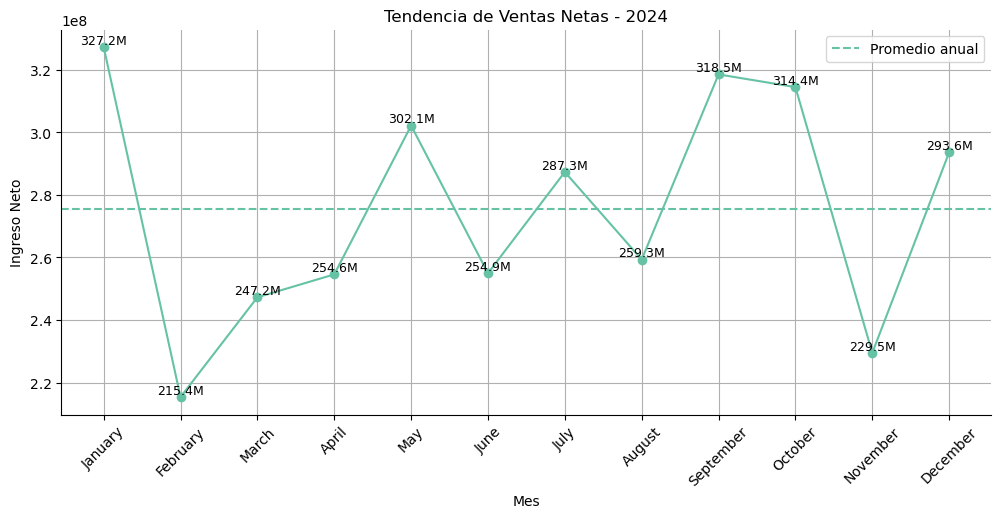

In [11]:
# VISUALIZACION 1 — Tendencia de ventas 2024
# TU CÓDIGO AQUÍ
ventas_mes = (
    df_metricas1.groupby(df_metricas1["fecha"].dt.month_name())["ingreso_neto"].sum()
)

orden_meses = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

ventas_mes = ventas_mes.reindex(orden_meses)

promedio_ventas = ventas_mes.mean()

plt.figure(figsize=(12,5))

plt.plot(
    ventas_mes.index,
    ventas_mes.values,
    marker="o")

plt.axhline(
    promedio_ventas,
    linestyle="--",
    label="Promedio anual")


for i, valor in enumerate(ventas_mes.values):
    plt.text(
        i,
        valor,
        f"{valor/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9)

plt.title("Tendencia de Ventas Netas - 2024")
plt.xlabel("Mes")
plt.ylabel("Ingreso Neto")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

**Insight visualización 1:** *A simple vista se observa que la tendencia no la podemos definir ni como alcista o bajista puesto a que es bastante irregular entre los periodos mensuales. Se puede observar que a inicios de año en Enero se tiene el pico más alto de ventas netas para luego pasar al punto más bajo de ventas (Febrero), esto podría ser perfectamente un efecto rebote que pasa 4 veces en total a lo largo del año. Se puede observar como cada vez que se supera la línea de promedio anual de ventas, estas vuelven a caer (Enero-Febrero; Mayo-Junio; Julio-Agosto) con excepción de septiembre a octubre donde se lograron mantener denotando un periodo de alto rendimiento comercial para finalizar con una recaida en noviembre y posterior crecimiento en diciembre lo que podría significar quizá una mejora de ventas para el siguiente año u otro efecto rebote. En general se puede concluir que es una tendencia de alta volatilidad e irregular con variaciones que podrían ser causadas por factores especificos como estacionales, regionales, tema de promoción, canales de venta, demanda del año, etc. Se debe centrar en estrategias para mantener un buen rendimiento de ventas o uno más regular si quiera evitando así los valles o recaidas*

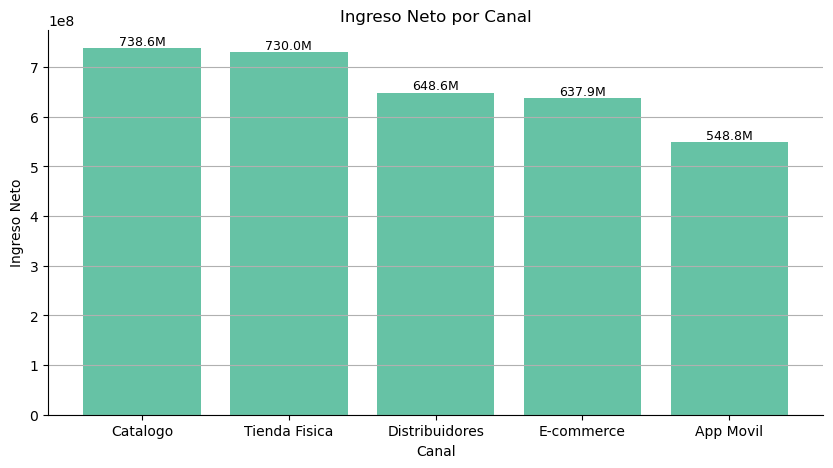

In [12]:
# VISUALIZACION 2 — Ingreso neto por canal
# TU CÓDIGO AQUÍ
ventas_canal = (
    df_metricas1.groupby("canal")["ingreso_neto"].sum().sort_values(ascending=False))



plt.figure(figsize=(10,5))
plt.bar(ventas_canal.index, ventas_canal.values)


for i, valor in enumerate(ventas_canal.values):
    plt.text(
        i,
        valor,
        f"{valor/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9)


plt.title("Ingreso Neto por Canal")
plt.xlabel("Canal")
plt.ylabel("Ingreso Neto")
plt.grid(axis="y")

plt.show()

**Insight visualización 2:** *Se puede observar que el canal que generó más ingresos (738M) es el catálogo y el que menos generó por otro lado es la app movil (549M). Importante recalcar que si bien el catálogo es el que generó más ingresos no existe mucha diferencia entre el segundo que más genero, siendo esta la Tienda Física, por otro lado, los dos canales restantes igual se encuentran igualados pero por encima de App Móvil. Podemos concluir que aunque no exista una diferencia abismal entre los ingresos de uno u otro canal, se deben priorizar aquellos que están más bajos, haciendo énfasis en la App Movil que es donde se deberían de implementar mejoras al respecto para igualar en ventas a los otros canales.*

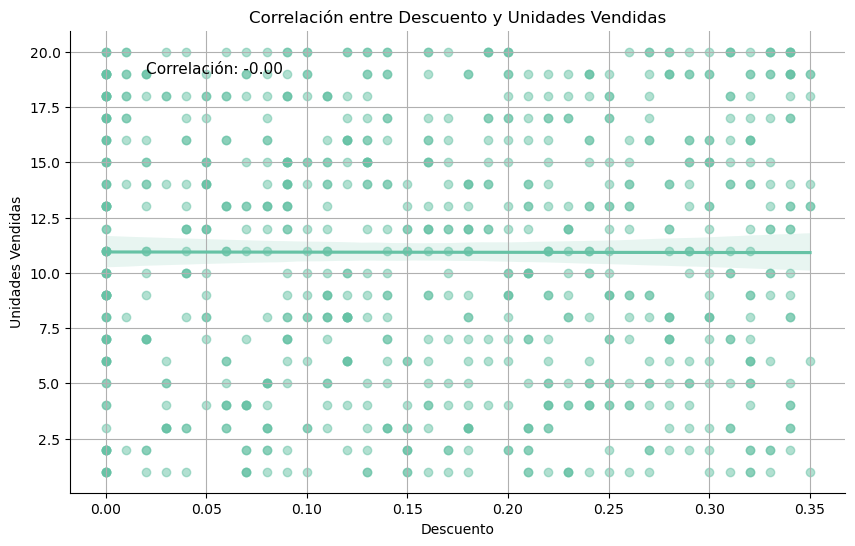

In [13]:
# VISUALIZACION 3 — Correlacion descuento vs unidades
# TU CÓDIGO AQUÍ
correlacion = (df_metricas1["descuento"].corr(df_metricas1["unidades"]))


plt.figure(figsize=(10,6))

sns.regplot(
    data=df_metricas1,
    x="descuento",
    y="unidades",
    scatter_kws={"alpha": 0.5})

plt.text(0.02, df_metricas1["unidades"].max() * 0.95,
    f"Correlación: {correlacion:.2f}",fontsize=11)

plt.title("Correlación entre Descuento y Unidades Vendidas")
plt.xlabel("Descuento")
plt.ylabel("Unidades Vendidas")

plt.grid(True)

plt.show()

**Insight visualización 3:** *Se puede observar una correlación con una dispersión alta entre observaciones que indica que no sigue ningún tipo de patrón por ende acorde al gráfico demostrado no existe correlación alguna entre Descuento y Unidades Vendidas*

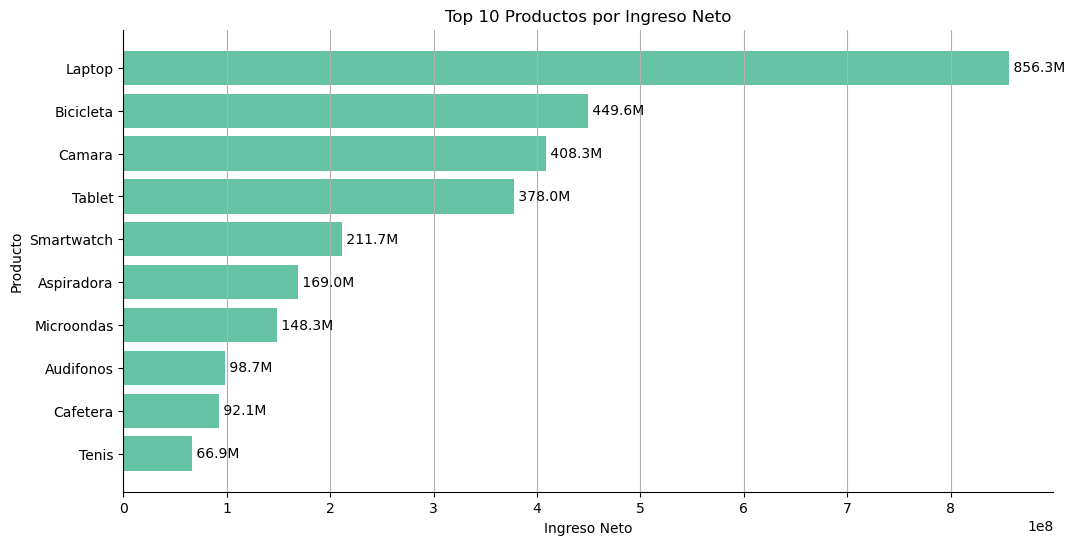

In [14]:
# VISUALIZACION EXTRA — Top productos por ingreso neto

top_productos = (df_metricas1.groupby("producto")["ingreso_neto"].sum().sort_values(ascending=False).head(10))


plt.figure(figsize=(12,6))
bars = plt.barh(
    top_productos.index,
    top_productos.values)

plt.gca().invert_yaxis()

for i, valor in enumerate(top_productos.values):
    plt.text(valor, i, f" {valor/1e6:.1f}M", va="center", fontsize=10)

plt.title("Top 10 Productos por Ingreso Neto")
plt.xlabel("Ingreso Neto")
plt.ylabel("Producto")

plt.grid(axis="x")

plt.show()

**Insight visualización 4 extra:** *El producto estrella de lejos es la laptop con una diferencia abismal de ingresos generados, esto puede deberse más que nada a la demanda y también al precio del producto. En base a esta información se podría enfocar en realizar campañas de promoción para generar más ingresos con los productos que menos generan, o al contrario, retirar aquellos que no son tan rentables para la compañia *

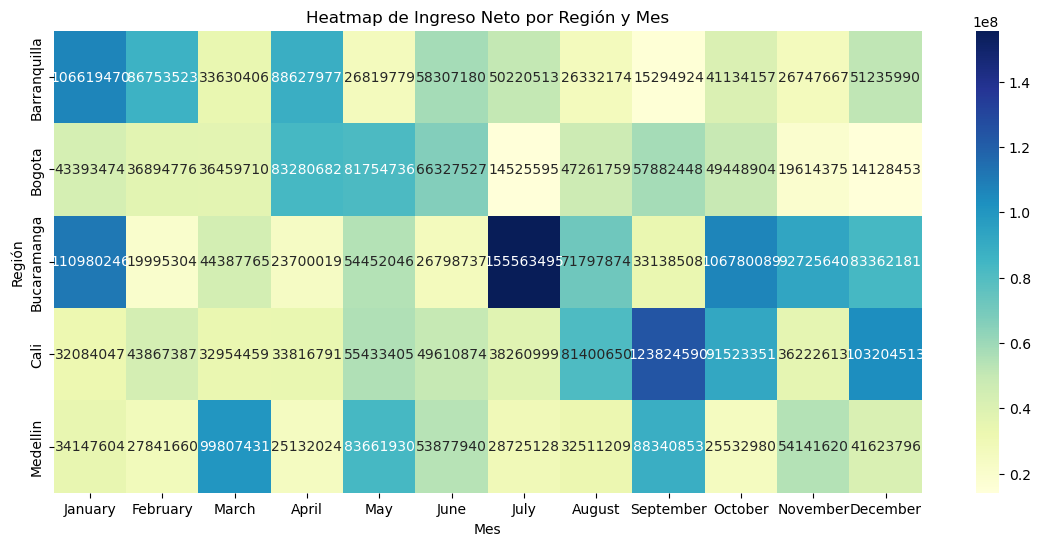

In [15]:
# VISUALIZACION EXTRA — Heatmap región vs mes

df_metricas1["mes_nombre"] = (df_metricas1["fecha"].dt.month_name())

orden_meses = ["January", "February", "March", "April",
               "May", "June", "July", "August",
               "September", "October", "November", "December"]


heatmap_data = (
    df_metricas1.pivot_table(values="ingreso_neto",
        index="region", columns="mes_nombre", aggfunc="sum"))

heatmap_data = heatmap_data[orden_meses]

plt.figure(figsize=(14,6))

sns.heatmap(heatmap_data, annot=True,
    fmt=".0f", cmap="YlGnBu")

plt.title("Heatmap de Ingreso Neto por Región y Mes")
plt.xlabel("Mes")
plt.ylabel("Región")

plt.show()

**Insight visualización 5 extra:** *Podemos observar un mapa de calor que nos marca el ingreso mensual por Región, podemos observar que de lejos el mes que más ingresos se producen es en Julio en la Región de Bucaramanga, y que en promedio es en esta región donde se generan más ingresos, mientras por otro lado, la Región que genera menos ingresos a la compañía es Barranquilla*

---
## Ejercicio 2.4 — Automatización (5 pts)

Crea una función `resumen_corte(df, region, mes)` que:
- Reciba el DataFrame limpio, una región y un mes (int 1-12)
- Retorne un diccionario con las métricas del ejercicio 2.2 para ese corte
- Incluya manejo de excepciones para entradas inválidas

In [ ]:
def resumen_corte(df: pd.DataFrame, region: str, mes: int) -> dict:
    """
    Retorna un resumen de métricas para una región y mes específicos.
    
    Parameters
    ----------
    df : DataFrame limpio con columnas fecha, region, unidades, precio, descuento
    region : nombre de la región (ej. 'Bogota')
    mes : número del mes (1-12)
    
    Returns
    -------
    dict con keys: region, mes, transacciones, ingreso_bruto, ingreso_neto, ticket_promedio
    
    Raises
    ------
    ValueError si mes no está en [1, 12] o si la región no existe
    TypeError si los tipos de parámetros son incorrectos
    """
    # TU CÓDIGO AQUÍ
    # VALIDACIÓN DE TIPOS
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un DataFrame")

    if not isinstance(region, str):
        raise TypeError("region debe ser texto")

    if not isinstance(mes, int):
        raise TypeError("mes debe ser un entero")
    
    # VALIDACIÓN DEL MES
    if mes < 1 or mes > 12:
        raise ValueError("El mes debe estar entre 1 y 12")
    
    # VALIDACIÓN DE REGIÓN
    if region not in df["region"].unique():
        raise ValueError("La región no existe")
    
    # FILTRADO DEL DATAFRAME
    df_filtrado = df[(df["region"] == region) & (df["fecha"].dt.month == mes)]

    # CANTIDAD DE TRANSACCIONES
    transacciones = len(df_filtrado)

    # INGRESO BRUTO
    ingreso_bruto = (df_filtrado["unidades"] * df_filtrado["precio"]).sum()

    # INGRESO NETO
    ingreso_neto = (df_filtrado["unidades"] * df_filtrado["precio"] * (1 - df_filtrado["descuento"])).sum()
    
    # TICKET PROMEDIO
    ticket_promedio = ingreso_neto / transacciones

    # RETORNO DEL DICCIONARIO
    return {
        "region": region,
        "mes": mes,
        "transacciones": transacciones,
        "ingreso_bruto": ingreso_bruto,
        "ingreso_neto": ingreso_neto,
        "ticket_promedio": ticket_promedio}

KeyboardInterrupt: 

In [17]:
# Pruebas de la función (no modificar)

# Prueba 1: llamada válida
resultado = resumen_corte(df, 'Bogota', 3)
assert isinstance(resultado, dict), 'Debe retornar un diccionario'
assert 'ingreso_neto' in resultado, 'Falta clave ingreso_neto'
print('✓ Prueba 1 OK:', resultado)

# Prueba 2: mes inválido
try:
    resumen_corte(df, 'Bogota', 13)
    print('✗ Prueba 2 FALLO: debió lanzar excepción')
except (ValueError, TypeError):
    print('✓ Prueba 2 OK: excepción capturada correctamente')

# Prueba 3: región inexistente
try:
    resumen_corte(df, 'Ciudad Inexistente', 6)
    print('✗ Prueba 3 FALLO: debió lanzar excepción')
except (ValueError, KeyError):
    print('✓ Prueba 3 OK: excepción capturada correctamente')

✓ Prueba 1 OK: {'region': 'Bogota', 'mes': 3, 'transacciones': 13, 'ingreso_bruto': 43803219, 'ingreso_neto': 36459709.730000004, 'ticket_promedio': 2804593.0561538464}
✓ Prueba 2 OK: excepción capturada correctamente
✓ Prueba 3 OK: excepción capturada correctamente


---
## Conclusiones Generales

*Durante el presente análisis  de datos del dataset de ventas se pudo observar o concluir una serie de factores clave o importante; Las ventas son muy irregulares, no siguen ningún patrón y esto representa inestabilidad comercial para la empresa; En cuanto a los canales de venta, se pudo observar que el ingreso generado por cada uno está más equilibrado o no existe diferencia extremadamente notable, el canal que menos ingresos generó sería la app Movil; Se pudo observar una clara y abismal diferencia numerica entre los ingresos generados clasificados por producto, concluyendo que algunos producos generan muy comparados a los más vendidos; También, se pudo observar que en general existe un desequilibrio notable en los ingresos mensuales generados por Región, siendo Bucaramanga la región que generó más ingresos y Barranquilla junto a Bogotá las que menos lo hicieron aunque las otras regiones están más cerca de la que menos general que de la que más lo hace siendo un problema importante. Algunas cuantas acciones a tomar en cuenta serían las siguientes:

-1. Realizar campañas dedicadas a la mejora del rendimiento comercial, planteando una estrategia que estabilice las ventas a lo largo del año, enfocada en los meses que peor le fue a la compañía en Ventas. 2. Realizar un análisis y mejora de cada canal enfocado en la App Movil investigando a profundidad por qué no es un canal viable y mejorar todo aspecto o re hacerla si es necesario. 3.Retirar los productos que menos ingresos generan y reinvertir los gastos recortados en los que si generan verdadera utilidad. 4.Realizar campañas publicitarias enfocadas en las regiones donde se detectaron menores ingresos.*